In [1]:
import sys 
sys.path.append('..')
from csbm import *
from tqdm import tqdm
import matplotlib.pyplot as plt

In [32]:
color_list=['#2a557f','#46bd9c','#ef5076','#facd6e']
color_list_two=[(7/255,7/255,7/255),(255/255,59/255,59/255)]

In [4]:
taulist=np.arange(0.01,0.99,0.04)
inum=len(taulist)
repeat=10

r_testacc=np.zeros((inum,repeat))
r_trainacc=np.zeros((inum,repeat))
r_testrisk=np.zeros((inum,repeat))
r_trainrisk=np.zeros((inum,repeat))
r_loss=np.zeros((inum,repeat))

for i, tau in enumerate(tqdm(taulist)):
    for ri in range(repeat):
        N=5000
        d=30
        gamma=5
        alpha=1/gamma
        lam=2
        mu=1
        r=0
        A,X,y=CSBM(N,alpha,d,lam,mu,matrix='BS',genX=True)

        r_trainacc[i,ri], r_testacc[i,ri],  r_trainrisk[i,ri], r_testrisk[i,ri], r_loss[i,ri]=LS(A,X,y,r,tau=tau)

100%|██████████| 25/25 [04:56<00:00, 11.85s/it]


In [7]:
def train_error(gamma,mu,lam,tau):
    return (gamma+mu)*(gamma*tau-1)/(gamma*tau*(gamma+lam**2*(mu+1)+mu))
def test_error(gamma,mu,lam,tau):
    return (gamma+mu)*(gamma*tau)/((tau*gamma-1)*(gamma+lam**2*(mu+1)+mu))

T_test_list_d=[]
T_train_list_d=[]
tau_list_d=np.arange(0.201,1,0.01)
for tau in tqdm(tau_list_d):
    T_train_list_d.append(train_error(gamma,mu,lam,tau))
    T_test_list_d.append(test_error(gamma,mu,lam,tau))

100%|██████████| 80/80 [00:00<00:00, 223398.35it/s]


In [1]:
# load from mathmatica

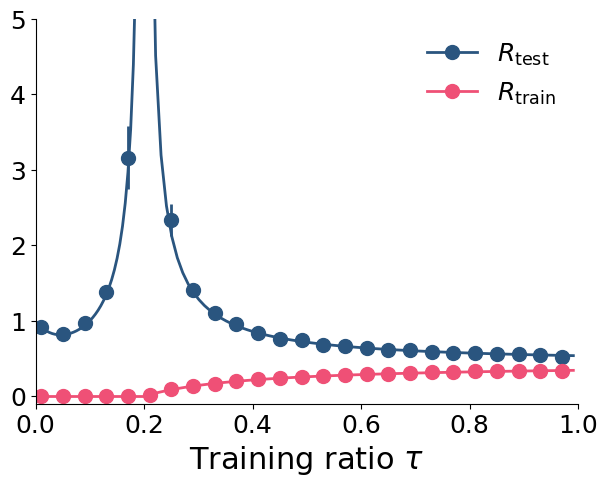

In [17]:
plt.rcParams["figure.figsize"] = (7,5)
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots()

dashes=[5,3]
legend_list=[]
p1=ax.plot(tau_list_n,T_testrisk,'-',linewidth=2,color=color_list[0])
p2=ax.errorbar(taulist,r_testrisk.mean(axis=1),r_testrisk.std(axis=1),fmt='o',color=color_list[0],capsize=0, elinewidth=2,markersize=10)
legend_list.append((p2[0], p1[0]))

p3=ax.plot(tau_list_n,T_trainrisk,'-',linewidth=2,color=color_list[-2])
p4=ax.errorbar(taulist,r_trainrisk.mean(axis=1),r_trainrisk.std(axis=1),fmt='o',color=color_list[-2],capsize=0, elinewidth=2,markersize=10)
legend_list.append((p3[0], p4[0]))
ax.legend(legend_list, [r'$R_{\mathrm{test}}$',r'$R_{\mathrm{train}}$'],frameon=False,fontsize=18)

ax.plot(tau_list_d,T_test_list_d,'-',linewidth=2,color=color_list[0])
ax.plot(tau_list_d,T_train_list_d,'-',linewidth=2,color=color_list[-2])




ax.set_ylim(-0.1,5)
ax.set_xlim(0,1)
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
ax.set_xlabel(r'Training ratio $\tau$',fontsize=22)
fig.savefig('f_v_r_new.pdf',bbox_inches='tight')

In [66]:
lambdalist=[0,1,2,3]
re=[]
for lam in lambdalist:
    taulist=np.arange(0.01,0.99,0.04)
    inum=len(taulist)
    repeat=10
    r_testacc=np.zeros((inum,repeat))
    r_trainacc=np.zeros((inum,repeat))
    r_testrisk=np.zeros((inum,repeat))
    r_trainrisk=np.zeros((inum,repeat))
    r_loss=np.zeros((inum,repeat))
    for i, tau in enumerate(tqdm(taulist)):
        for ri in range(repeat):
            N=5000
            d=30
            gamma=2
            alpha=1/gamma
            #lam=2
            mu=1
            r=0.02
            A,X,y=CSBM(N,alpha,d,lam,mu,matrix='BS',genX=True)
            r_trainacc[i,ri], r_testacc[i,ri],  r_trainrisk[i,ri], r_testrisk[i,ri], r_loss[i,ri]=LS(A,X,y,r,tau=tau)
    re.append(r_testrisk)

100%|██████████| 25/25 [09:18<00:00, 22.35s/it]


In [2]:
# load from mathmatica

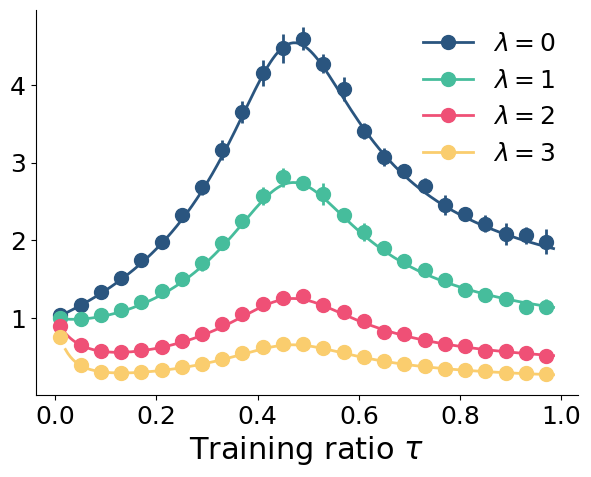

In [69]:
plt.rcParams["figure.figsize"] = (7,5)
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots()

dashes=[5,3]
legend_list=[]
for i in range(4):
    r_testrisk=re[i]
    p1=ax.errorbar(taulist,r_testrisk.mean(axis=1),r_testrisk.std(axis=1),fmt='o',color=color_list[i],capsize=0, elinewidth=2,markersize=10)
    p2=ax.plot(lt[i],lr[i],'-',color=color_list[i],linewidth=2)
    legend_list.append((p1[0], p2[0]))


ax.legend(legend_list, [r'$\lambda=0$',r'$\lambda=1$',r'$\lambda=2$',r'$\lambda=3$'],frameon=False,fontsize=18)
#ax.set_xlabel(r'$\tau$',fontsize=22)
ax.set_xlabel(r'Training ratio $\tau$',fontsize=22)
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
fig.savefig('f_v_l.pdf',bbox_inches='tight')

In [70]:
rlist=[0.01,0.1,1,5]
re=[]
for r in rlist:
    taulist=np.arange(0.01,0.99,0.04)
    inum=len(taulist)
    repeat=10
    r_testacc=np.zeros((inum,repeat))
    r_trainacc=np.zeros((inum,repeat))
    r_testrisk=np.zeros((inum,repeat))
    r_trainrisk=np.zeros((inum,repeat))
    r_loss=np.zeros((inum,repeat))
    for i, tau in enumerate(tqdm(taulist)):
        for ri in range(repeat):
            N=5000
            d=30
            gamma=2
            alpha=1/gamma
            lam=3
            mu=1
            #r=0.02
            A,X,y=CSBM(N,alpha,d,lam,mu,matrix='BS',genX=True)
            r_trainacc[i,ri], r_testacc[i,ri],  r_trainrisk[i,ri], r_testrisk[i,ri], r_loss[i,ri]=LS(A,X,y,r,tau=tau)
    re.append(r_testrisk)

100%|██████████| 25/25 [10:06<00:00, 24.24s/it]


In [71]:
# load from mathmatica

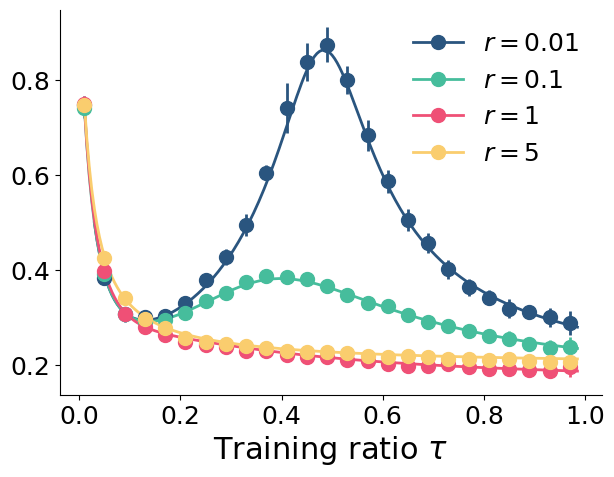

In [73]:
plt.rcParams["figure.figsize"] = (7,5)
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots()

dashes=[5,3]
legend_list=[]
for i in range(4):
    r_testrisk=re[i]
    p1=ax.errorbar(taulist,r_testrisk.mean(axis=1),r_testrisk.std(axis=1),fmt='o',color=color_list[i],capsize=0, elinewidth=2,markersize=10)
    p2=ax.plot(lt[i],lr[i],color=color_list[i],linewidth=2)
    legend_list.append((p1[0], p2[0]))


ax.legend(legend_list, [r'$r=0.01$',r'$r=0.1$',r'$r=1$',r'$r=5$'],frameon=False,fontsize=18)
#ax.set_xlabel(r'$\tau$',fontsize=22)
ax.set_xlabel(r'Training ratio $\tau$',fontsize=22)
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
fig.savefig('f_v_r.pdf',bbox_inches='tight')